## UNet model

In [1]:
import torch
import cv2
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms
from PIL import Image


In [2]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/images/20878930_15_patch_3.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/masks/20878930_15_patch_3.png"

In [3]:
from Unet_model import UNet

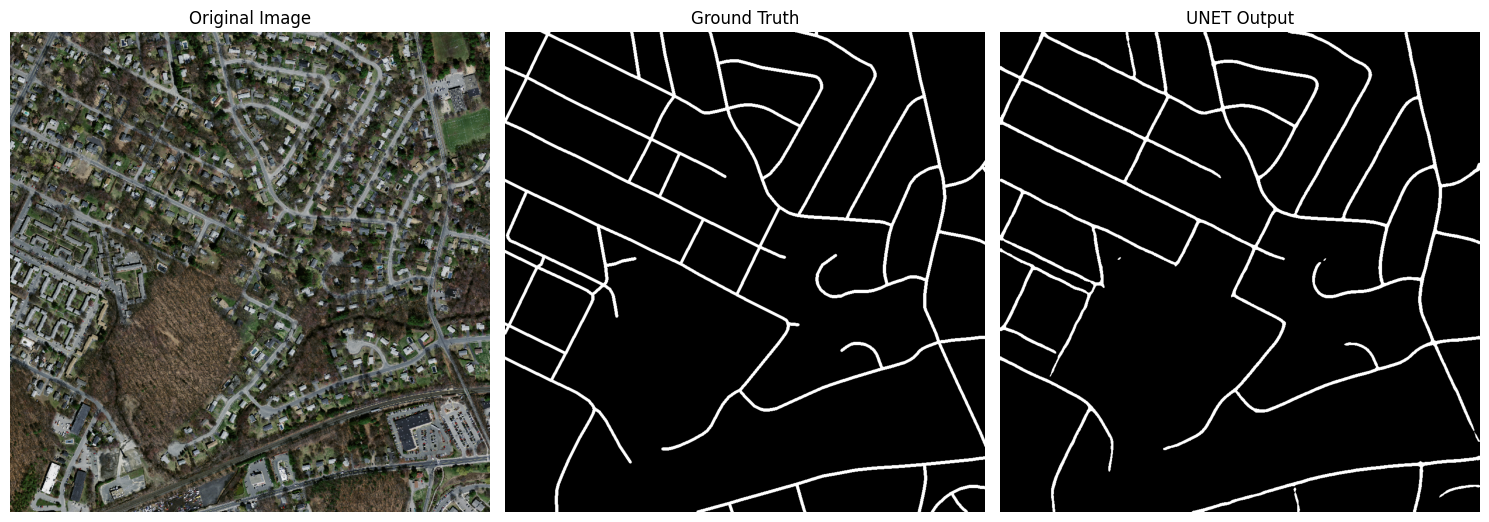

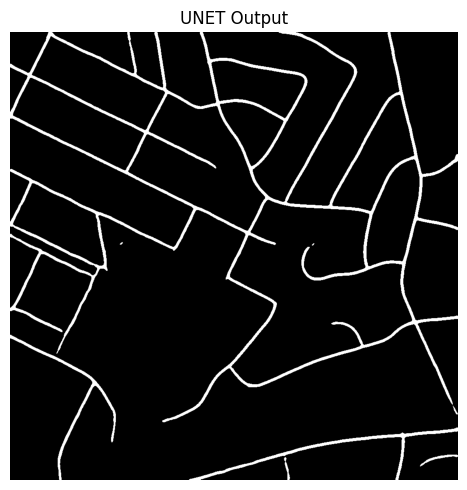

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)

my_model = UNet()
my_model.load_state_dict(torch.load("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/unet/unet_rooftop_50_2.pth"))
my_model.to(device=device)
my_model.eval()

with torch.no_grad():
    unet_out = my_model(image_batch)  # (1, 1, H, W)
    
    unet_mask = (unet_out > 0.5).float()

def to_numpy(t):
    return t.squeeze().detach().cpu().numpy()

original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = to_numpy(mask)
pred_mask_np = to_numpy(unet_mask) 

titles = ["Original Image", "Ground Truth","UNET Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/unet/UNET_demo_predicted_mask.png")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(pred_mask_np, cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/unet/UNET_demo_predicted_mask_only.png")
plt.show()

## DeepLabV3

In [6]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from PIL import Image
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt

In [7]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/images/20878930_15_patch_3.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/masks/20878930_15_patch_3.png"

(1, 1, 1024, 1024)


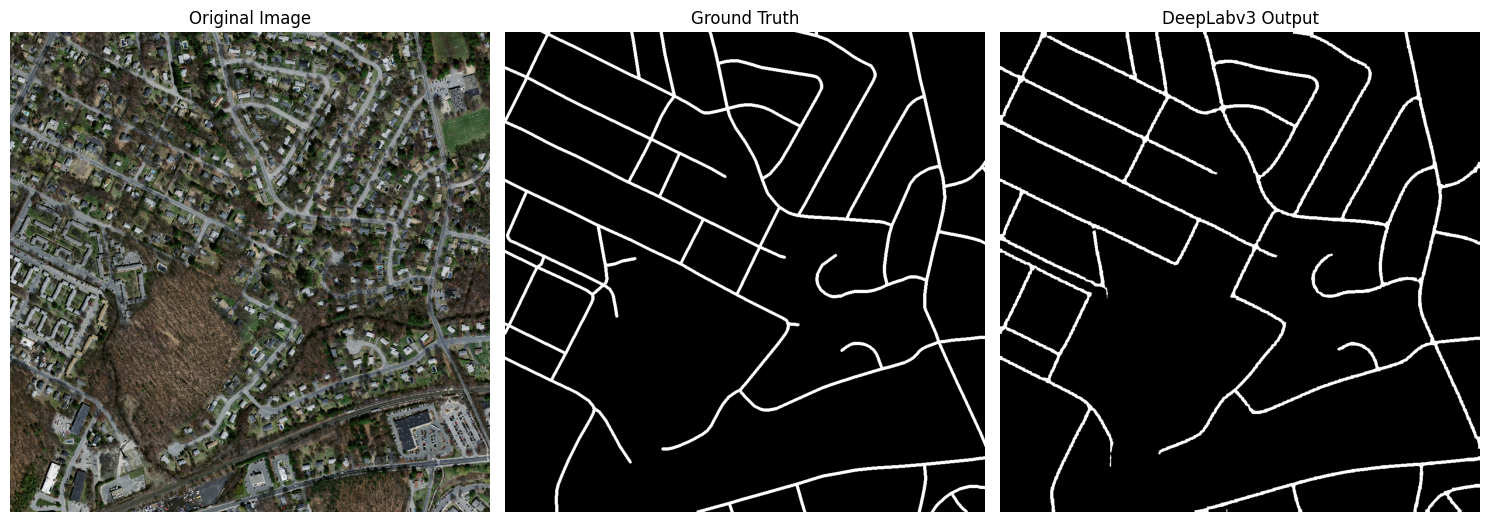

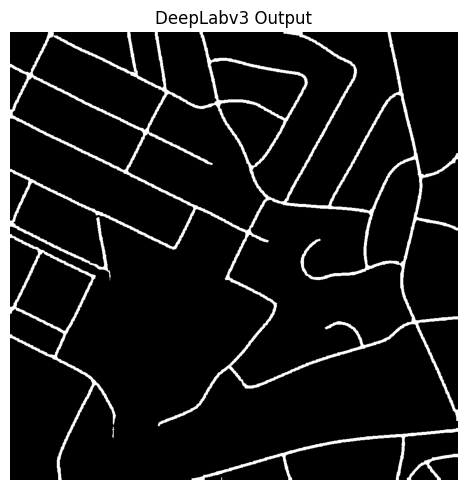

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)


model = torch.load("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/deeplabv3/deeplab_rooftop_full_50.pth", weights_only=False)
model.to(device)
model.eval()

with torch.no_grad():
    outputs = model(image_batch)["out"]
    preds = torch.sigmoid(outputs) > 0.5
    preds = preds.cpu().numpy().astype(np.uint8)

print(preds.shape)

original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = mask.reshape(1024,1024)
pred_mask_np = preds.reshape(1024,1024)

titles = ["Original Image", "Ground Truth","DeepLabv3 Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/deeplabv3//DEEPLABV3_demo_predicted_mask.png")
plt.show()


plt.figure(figsize=(5,5))
plt.imshow(pred_mask_np, cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/deeplabv3//DEEPLABV3_demo_predicted_mask_only.png")
plt.show()

## Mask RCNN

In [10]:
import torch
import torchvision
import torchvision.transforms as T
import os
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
import torchvision.transforms.functional as TF
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

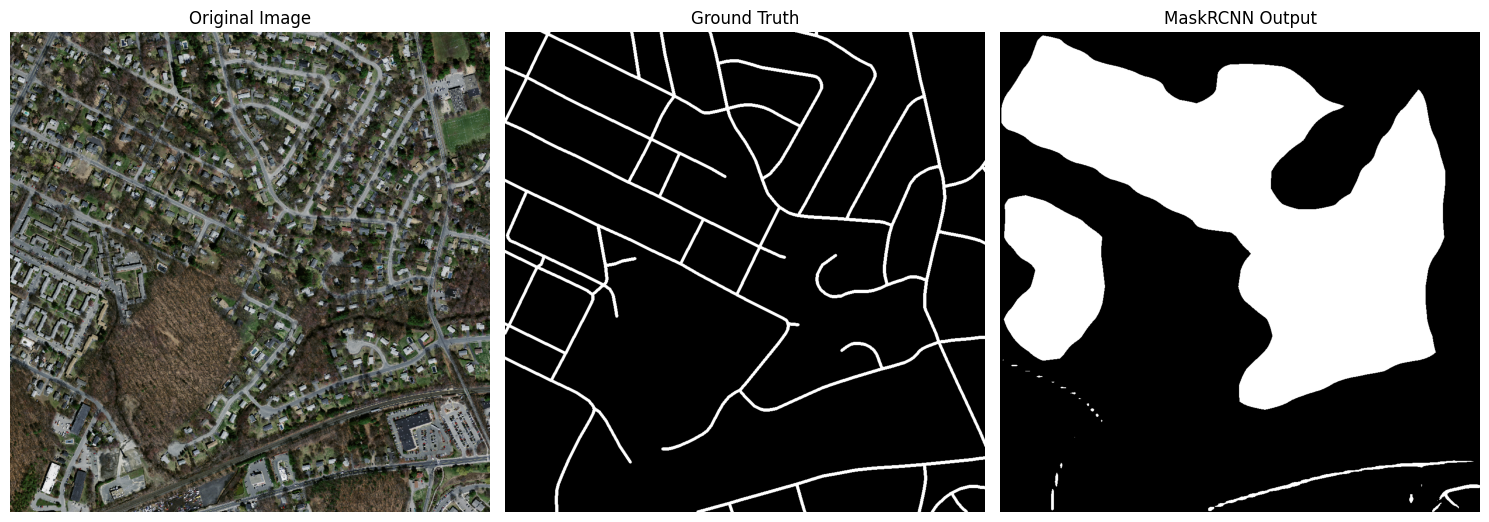

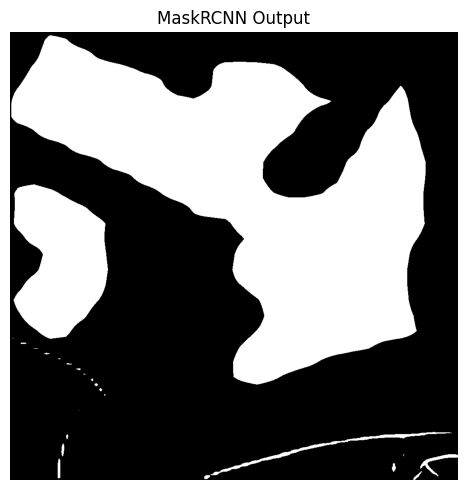

In [11]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/images/20878930_15_patch_3.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/masks/20878930_15_patch_3.png"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
ground_mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)

model_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/maskrcnn/mask_rcnn_epoch_50_full.pth"
my_model = torch.load(model_path, weights_only=False)
my_model.to(device)
my_model.eval()


with torch.no_grad():
    output = my_model(image_batch)[0]

keep = output["scores"] >= 0.5
boxes = output["boxes"][keep].cpu().numpy()
labels = output["labels"][keep].cpu().numpy()
masks = output["masks"][keep].squeeze(1).cpu().numpy()  # Shape: (N, H, W)

final_mask = torch.zeros((1024,1024), dtype=torch.float32)

for mask in masks:
    bin_mask = (mask > 0.5).astype(np.uint8)
    bin_mask_pil = TF.to_pil_image(bin_mask)
    resized_mask = TF.to_tensor(TF.resize(bin_mask_pil, (1024,1024))).squeeze(0)
    
    # Combine using logical OR
    final_mask = torch.logical_or(final_mask, resized_mask).float()
    
    
original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = ground_mask.reshape(1024,1024)
pred_mask_np = final_mask

titles = ["Original Image", "Ground Truth","MaskRCNN Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/maskrcnn/MaskRCNN_demo_predicted_mask.png")
plt.show()


plt.figure(figsize=(5,5))
plt.imshow(pred_mask_np, cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/maskrcnn/MaskRCNN_demo_predicted_mask_only.png")
plt.show()

## YOLO v12 + SAM

In [1]:
import os
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION'

In [3]:
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection")

In [5]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
from Solar_Rooftop_Detection.accuracy import compute_metrics
from Solar_Rooftop_Detection.generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/images/20878930_15_patch_3.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/masks/20878930_15_patch_3.png"

image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

yolo_model = YOLO("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/yolov12/best.pt")
sam = sam_model_registry["vit_b"]("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/sam_check_point/Final_Models/FineTune_model_0_epoch_28_01_05_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
sam_predictor
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
# boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# # print(boxes)
# gt_mask = torch.from_numpy(mask).to("cuda")
# sam_predictor.set_image(image)
# H, W = image.shape[:2]
# # print(H, W)
# # Create a combined mask with the same shape as the image
# combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
# combined_mask = combined_mask.to("cuda")
# print(combined_mask.shape)

# for box in boxes:
#     x1, y1, x2, y2 = map(int, box)
    
#     masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
#     pred_mask = masks[0]
#     pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
#     # print(pred_mask.shape)
#     combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

# titles = ["Original Image", "Ground Truth","YOLOv10 + SAM"]

# images = [
#     image,
#     gt_mask.cpu().numpy(),
#     combined_mask.cpu().numpy()[0]
# ]

# plt.figure(figsize=(15, 10))
# for i, (img, title) in enumerate(zip(images, titles)):
#     plt.subplot(1, 3, i + 1)
#     plt.imshow(img, cmap='gray' if i != 0 else None)
#     plt.title(title)
#     plt.axis('off')

# plt.tight_layout()
# # plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/yolov10_sam_predicted_mask.png")
# plt.show()


AttributeError: 'AAttn' object has no attribute 'qkv'

## DETR + SAM

In [16]:
import os
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection")

In [17]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from Solar_Rooftop_Detection.accuracy import compute_metrics
from Solar_Rooftop_Detection.generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns
from rfdetr import RFDETRBase

In [18]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/images/20878930_15_patch_3.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/test/masks/20878930_15_patch_3.png"

image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

Loading pretrain weights
torch.Size([1, 1024, 1024])


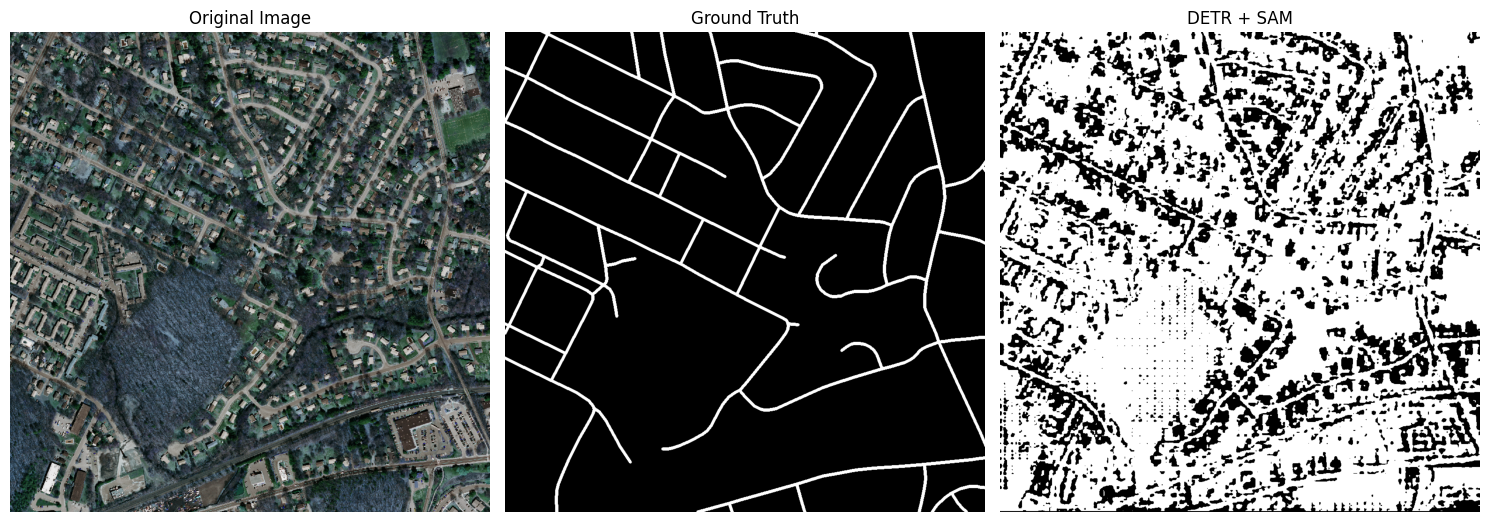

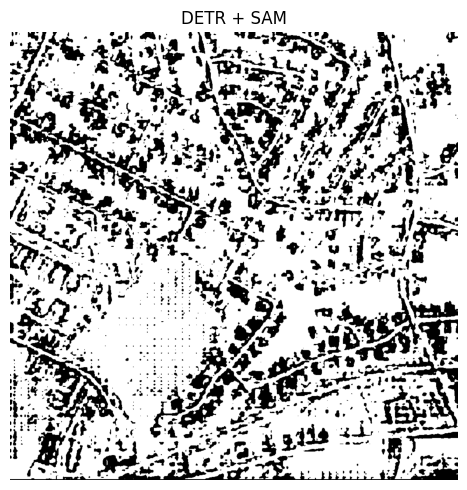

In [21]:
checkpoint_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/detr/checkpoint_best_total.pth"  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_wrapper = RFDETRBase()
underlying_model = model_wrapper.model
underlying_model.reinitialize_detection_head(num_classes=2)
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
pytorch_model = underlying_model.model
pytorch_model.load_state_dict(checkpoint['model'])

pytorch_model.to(device)
pytorch_model.eval()

sam = sam_model_registry["vit_b"]("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/sam_check_point/Final_Models/FineTune_model_0_epoch_28_01_05_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
detections = model_wrapper.predict(image, threshold=0.5)
boxes = detections.xyxy

# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","DETR + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/sam/sam_detr_demo_predicted_mask.png")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(combined_mask.cpu().numpy()[0], cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/sam/sam_detr_demo_predicted_mask_only.png")
plt.show()